In [ ]:
#Загрузка датасета
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz
!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2025-04-16 04:39:44--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Resolving www.soshnikov.com (www.soshnikov.com)... 79.137.227.122
Connecting to www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24483412 (23M) [application/x-tar]
Saving to: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M   124KB/s    in 3m 19s  

2025-04-16 04:43:04 (120 KB/s) - ‘petfaces.tar.gz’ saved [24483412/24483412]



In [ ]:
#Импорт модулей
!pip install keras-tuner
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import numpy as np
from collections import Counter
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
import shutil
import re

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 11.7 MB/s eta 0:00:00


In [ ]:
#Функция показа изображений
def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

In [ ]:
#Обработка изображений
ds_train, ds_test = tf.keras.preprocessing.image_dataset_from_directory(
    "petfaces",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='both',
    crop_to_aspect_ratio=True,
    verbose=True
)

classes = ds_train.class_names

for x,y in ds_train:
  print(x.shape,y.shape)
  print(tf.reduce_max(x))
  break


all_labels = []
for _, labels in ds_train:
    all_labels.extend(labels.numpy())

label_counts = Counter(all_labels)

class_counts = np.array([label_counts.get(i, 0) for i in range(len(classes))])
class_weights = 1.0 / class_counts
class_weights = class_weights / np.sum(class_weights)
class_weights_dict = {i: class_weights[i] for i in range(len(classes))}

print("Классы и количество примеров:")
for class_index, count in label_counts.items():
    print(f"{classes[class_index]}: {count}")

Found 3211 files belonging to 35 classes.
Using 2569 files for training.
Using 642 files for validation.
(32, 64, 64, 3) (32,)
tf.Tensor(255.0, shape=(), dtype=float32)
Классы и количество примеров:
cat_British: 85
dog_chihuahua: 69
dog_wheaten: 68
dog_german: 54
cat_Bombay: 78
dog_pug: 75
dog_saint: 68
cat_Maine: 78
dog_havanese: 79
cat_Russian: 73
dog_beagle: 63
cat_Persian: 70
dog_leonberger: 79
dog_english: 138
cat_Abyssinian: 76
dog_basset: 72
dog_scottish: 50
dog_american: 133
dog_yorkshire: 58
cat_Ragdoll: 77
cat_Sphynx: 78
cat_Bengal: 58
dog_boxer: 66
dog_great: 78
dog_japanese: 59
dog_staffordshire: 71
dog_miniature: 61
cat_Birman: 81
dog_shiba: 65
cat_Siamese: 81
dog_pomeranian: 68
cat_Egyptian: 57
dog_newfoundland: 81
dog_samoyed: 54
dog_keeshond: 68


In [ ]:
#Оптимизация параметров модели и аугментация
def build_model(hp):

    augmentation = tf.keras.Sequential([
          tf.keras.layers.RandomFlip("horizontal"),
          tf.keras.layers.RandomRotation(0.1),
          tf.keras.layers.RandomZoom(0.1),
          tf.keras.layers.RandomTranslation(0.1, 0.1),
      ])

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(64,64,3)),
        augmentation,
        tf.keras.layers.Rescaling(1/255.),
        tf.keras.layers.Conv2D(hp.Int('filters1', 8, 64, step=8), (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(hp.Int('filters2', 8, 64, step=8), (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(hp.Int('dense_units', 32, 128, step=32), activation='relu'),
        tf.keras.layers.Dense(len(classes), activation='softmax')
    ])



    optimizer_choice = hp.Choice('optimizer', ['adam', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', values=[0.0001, 0.0005, 0.001, 0.005])

    if optimizer_choice == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']),
        loss='sparse_categorical_crossentropy',
        metrics=['acc']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_acc',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='hyperparameter5'
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,               # Количество эпох без улучшения, прежде чем остановить обучение
    restore_best_weights=True
)

tuner.search(ds_train, validation_data=ds_test, epochs=10, class_weight=class_weights_dict, callbacks=[early_stopping])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")

Trial 10 Complete [00h 01m 56s]
val_acc: 0.23831775784492493

Best val_acc So Far: 0.41588786244392395
Total elapsed time: 00h 31m 37s
Best hyperparameters:
filters1: 40
filters2: 64
dense_units: 128
optimizer: adam
learning_rate: 0.005


In [ ]:
#Обучение модели
model = build_model(best_hps)
history = model.fit(ds_train, validation_data=ds_test, epochs=80, class_weight=class_weights_dict)

Epoch 1/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - acc: 0.0422 - loss: 0.0975 - val_acc: 0.0794 - val_loss: 3.4918
Epoch 2/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 258ms/step - acc: 0.0968 - loss: 0.0876 - val_acc: 0.1682 - val_loss: 3.0906
Epoch 3/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - acc: 0.1708 - loss: 0.0782 - val_acc: 0.2555 - val_loss: 2.7809
Epoch 4/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 41s 257ms/step - acc: 0.2127 - loss: 0.0733 - val_acc: 0.2991 - val_loss: 2.6558
Epoch 5/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - acc: 0.2577 - loss: 0.0698 - val_acc: 0.3255 - val_loss: 2.5684
Epoch 6/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - acc: 0.3034 - loss: 0.0651 - val_acc: 0.3489 - val_loss: 2.4379
Epoch 7/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 266ms/step - acc: 0.3461 - loss: 0.0622 - val_acc: 0.3069 - val_loss: 2.4883
Epoch 8/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 40s 254ms/step - acc: 0.3584 - loss: 0.0603 - val_acc: 0.3614 - val_loss: 2.2881
Epoch 9/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 40s 237ms/

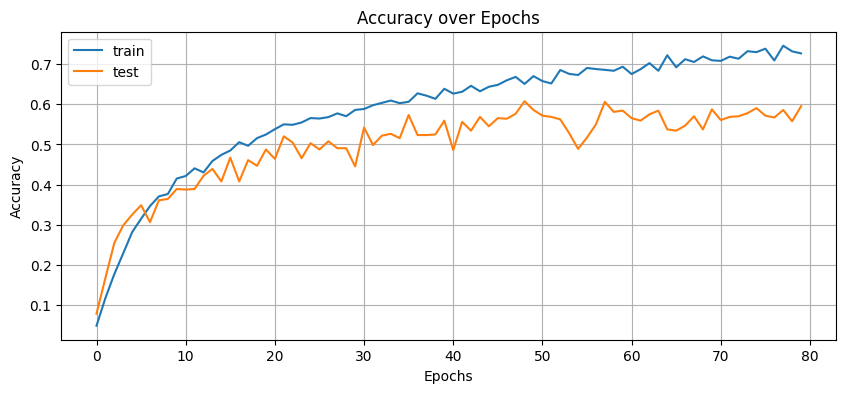

In [ ]:
#Построение графика
plt.figure(figsize=(10,4))
plt.plot(history.history['acc'],label='train')
plt.plot(history.history['val_acc'],label='test')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.grid()
plt.legend()
plt.show()

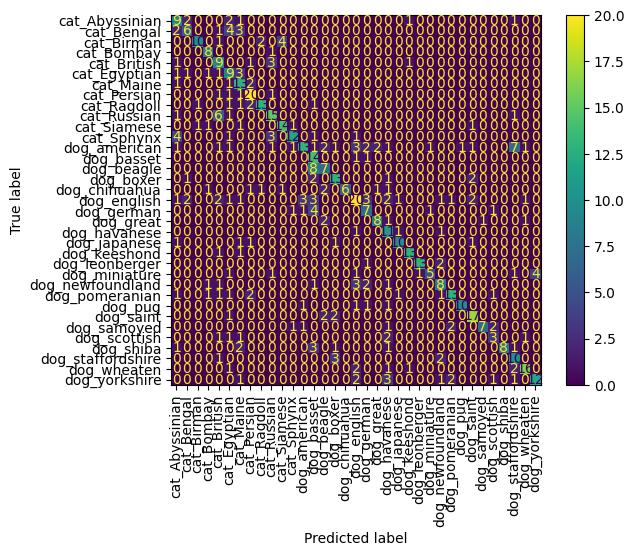

In [ ]:
#Матрица ошибок многоклассовой клкассификации
pred_y = []
true_y = []
for x,y in ds_test:
  pred_y.extend(model.predict(x,verbose=0).argmax(axis=-1))
  true_y.extend(y)

ConfusionMatrixDisplay.from_predictions(true_y,pred_y,display_labels=classes)
plt.xticks(rotation=90)
plt.show()

Accuracy = 0.9190031152647975


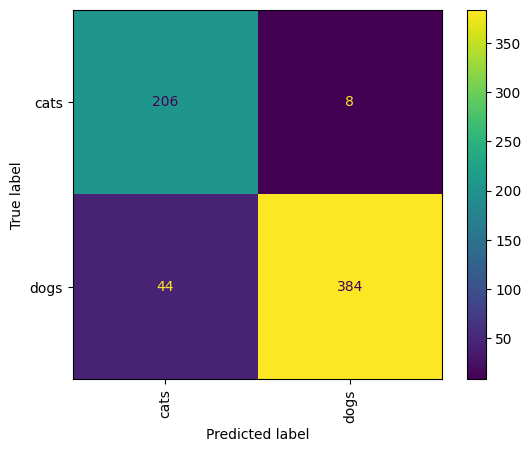

In [ ]:
#Проверка, сколько кошек остались кошками, а сколько собак собаками и построение матрицы ошибок при многоклассовом классификаторе
pred_y = []
true_y = []

classmap = { x : 0 if c.startswith('cat') else 1 for x,c in enumerate(classes)}
def cmap(x):
  return [ classmap[i] for i in x ]

for x,y in ds_test:
  pred_y.extend(cmap(model.predict(x,verbose=0).argmax(axis=-1)))
  true_y.extend(cmap(y.numpy()))

print(f"Accuracy = {accuracy_score(true_y,pred_y)}")
ConfusionMatrixDisplay.from_predictions(true_y,pred_y,display_labels=['cats','dogs'])
plt.xticks(rotation=90)
plt.show()

In [ ]:
#top-3 при многоклассовом классификаторе
top_k = 3

top_3_correct = 0
total = 0

for x, y in ds_test:
    preds = model.predict(x, verbose=1)
    for i in range(len(y)):
        top_3_preds = np.argsort(preds[i])[-top_k:][::-1]
        if y[i] in top_3_preds:
            top_3_correct += 1
        total += 1

top_3_accuracy = top_3_correct / total
print(f"Top-3 Accuracy = {top_3_accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Top-3 Accuracy = 0.8052959501557633


--2025-04-15 02:58:21--  https://kot-pes.com/wp-content/uploads/2019/02/post_5c606e629f934.jpg
Resolving kot-pes.com (kot-pes.com)... 104.21.96.1, 104.21.48.1, 104.21.64.1, ...
Connecting to kot-pes.com (kot-pes.com)|104.21.96.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 161127 (157K) [image/jpeg]
Saving to: ‘post_5c606e629f934.jpg.6’

post_5c606e629f934. 100%[===================>] 157.35K  --.-KB/s    in 0.01s   

2025-04-15 02:58:21 (14.1 MB/s) - ‘post_5c606e629f934.jpg.6’ saved [161127/161127]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Предсказанный класс:  dog_japanese


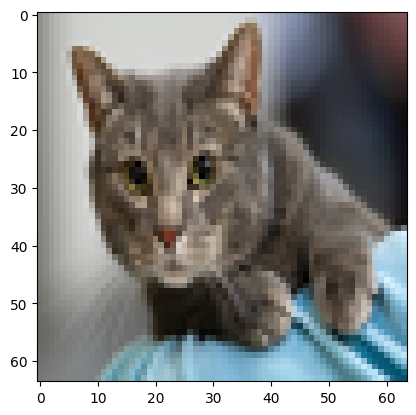

In [ ]:
#Проверка на отдельном изображении многоклассового классификатора
!wget https://kot-pes.com/wp-content/uploads/2019/02/post_5c606e629f934.jpg
#!wget https://funik.ru/wp-content/uploads/2018/10/17478da42271207e1d86.jpg
img = np.array(Image.open('post_5c606e629f934.jpg').resize((64,64),Image.LANCZOS))
plt.imshow(img)

img_array = np.array(img).astype("float32") / 255.0
img_batch = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_batch)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = classes[predicted_class[0]]
print("Предсказанный класс: ", predicted_label)

In [ ]:
directory_path = 'petfaces'

absolute_path = os.path.abspath(directory_path)
print("Абсолютный путь к директории petfaces:", absolute_path)

directory_contents = os.listdir(directory_path)
print("Содержимое директории petfaces:", directory_contents)

Абсолютный путь к директории petfaces: /content/petfaces
Содержимое директории petfaces: ['dog_basset', 'dog_scottish', 'dog_pomeranian', 'dog_newfoundland', 'dog_great', 'dog_havanese', 'dog_english', 'dog_american', 'cat_Egyptian', 'cat_Russian', 'dog_saint', 'cat_Siamese', 'dog_chihuahua', 'cat_Sphynx', 'cat_British', 'dog_japanese', 'dog_beagle', 'dog_wheaten', 'cat_Bengal', 'cat_Ragdoll', 'cat_Bombay', 'dog_leonberger', 'dog_miniature', 'dog_german', 'dog_boxer', 'cat_Abyssinian', 'cat_Maine', 'dog_samoyed', 'dog_pug', 'dog_yorkshire', 'dog_shiba', 'dog_keeshond', 'dog_staffordshire', 'cat_Persian', 'cat_Birman']


In [ ]:
#--- Классификация изображений на кошек и собак при помощи бинарного классификатора ---
#Предобработка меток
cat_breeds = ['cat_Abyssinian','cat_Bombay', 'cat_Russian', 'cat_Maine', 'cat_Siamese', 'cat_Birman', 'cat_British', 'cat_Sphynx', 'cat_Bengal', 'cat_Egyptian', 'cat_Persian', 'cat_Ragdoll']
dog_breeds = ['dog_samoyed', 'dog_japanese', 'dog_boxer', 'dog_havanese', 'dog_scottish', 'dog_german', 'dog_pomeranian', 'dog_staffordshire', 'dog_great', 'dog_pug', 'dog_newfoundland', 'dog_basset', 'dog_american', 'dog_shiba', 'dog_saint', 'dog_beagle', 'dog_chihuahua', 'dog_keeshond', 'dog_wheaten', 'dog_leonberger', 'dog_yorkshire', 'dog_miniature', 'dog_english']

working_path = '/content/petfaces'
cats_folder = os.path.join(working_path, 'cats_folder')
dogs_folder = os.path.join(working_path, 'dogs_folder')

if os.path.exists(cats_folder):
  shutil.rmtree(cats_folder)
  print(f"Папка {cats_folder} была удалена!")
else:
  print(f"Папка {cats_folder} не найдена!")

if os.path.exists(dogs_folder):
  shutil.rmtree(dogs_folder)
  print(f"Папка {dogs_folder} была удалена!")
else:
  print(f"Папка {dogs_folder} не найдена!")

os.makedirs(cats_folder, exist_ok=True)
os.makedirs(dogs_folder, exist_ok=True)

def classify_images(images_path):
    categories = os.listdir(images_path)
    print("Категории:", categories)

    categories = [category for category in categories if category not in ['cats_folder', 'dogs_folder']]

    for category in categories:
        category_path = os.path.join(images_path, category)

        if not os.path.isdir(category_path):
            continue

        if 'cat' in category.lower():
            category_folder = cats_folder
        elif 'dog' in category.lower():
            category_folder = dogs_folder
        else:
            continue

        for image_name in os.listdir(category_path):
            image_path = os.path.join(category_path, image_name)
            if image_path.endswith('.jpg') or image_path.endswith('.png'):
                shutil.copy(image_path, category_folder)


classify_images(working_path)

directory_contents = os.listdir(directory_path)
print("Содержимое директории cats_folder:", os.listdir("/content/petfaces/cats_folder"))
print("Содержимое директории dogs_folder:", os.listdir("/content/petfaces/dogs_folder"))


all_folders = os.listdir(working_path)
for folder in all_folders:
    folder_path = os.path.join(working_path, folder)

    if os.path.isdir(folder_path) and folder_path != cats_folder and folder_path != dogs_folder:
        shutil.rmtree(folder_path)
        print(f"Папка {folder_path} была удалена!")

Папка /content/petfaces/cats_folder не найдена!
Папка /content/petfaces/dogs_folder не найдена!
Категории: ['dog_basset', 'dog_scottish', 'dog_pomeranian', 'dog_newfoundland', 'dog_great', 'dog_havanese', 'dog_english', 'dog_american', 'cat_Egyptian', 'cat_Russian', 'dog_saint', 'cat_Siamese', 'dog_chihuahua', 'cat_Sphynx', 'cat_British', 'dog_japanese', 'dog_beagle', 'dog_wheaten', 'cat_Bengal', 'cat_Ragdoll', 'cat_Bombay', 'dog_leonberger', 'dog_miniature', 'dog_german', 'dog_boxer', 'cat_Abyssinian', 'cat_Maine', 'dog_samoyed', 'cats_folder', 'dog_pug', 'dog_yorkshire', 'dogs_folder', 'dog_shiba', 'dog_keeshond', 'dog_staffordshire', 'cat_Persian', 'cat_Birman']
Содержимое директории cats_folder: ['Persian_105.jpg', 'Maine_Coon_182.jpg', 'Maine_Coon_141.jpg', 'Abyssinian_130.jpg', 'Ragdoll_159.jpg', 'Maine_Coon_148.jpg', 'Birman_165.jpg', 'Abyssinian_122.jpg', 'Siamese_148.jpg', 'Bengal_116.jpg', 'Egyptian_Mau_131.jpg', 'Birman_130.jpg', 'Egyptian_Mau_160.jpg', 'Russian_Blue_185.jpg

In [ ]:
#Обработка изображений бинарного классификатора
ds_train, ds_test = tf.keras.preprocessing.image_dataset_from_directory(
    "petfaces",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='both',
    crop_to_aspect_ratio=True,
    verbose=True
)

classes = ds_train.class_names

for x,y in ds_train:
  print(x.shape,y.shape)
  print(tf.reduce_max(x))
  break


all_labels = []
for _, labels in ds_train:
    all_labels.extend(labels.numpy())

label_counts = Counter(all_labels)

class_counts = np.array([label_counts.get(i, 0) for i in range(len(classes))])
class_weights = 1.0 / class_counts
class_weights = class_weights / np.sum(class_weights)
class_weights_dict = {i: class_weights[i] for i in range(len(classes))}

print("Классы и количество примеров:")
for class_index, count in label_counts.items():
    print(f"{classes[class_index]}: {count}")

Found 3211 files belonging to 2 classes.
Using 2569 files for training.
Using 642 files for validation.
(32, 64, 64, 3) (32,)
tf.Tensor(255.0, shape=(), dtype=float32)
Классы и количество примеров:
cats_folder: 892
dogs_folder: 1677


In [ ]:
#Подбор подходящей модели для бинарного классификатора
#Оптимизация параметров модели и аугментация
def build_model(hp):

    augmentation = tf.keras.Sequential([
          tf.keras.layers.RandomFlip("horizontal"),
          tf.keras.layers.RandomRotation(0.1),
          tf.keras.layers.RandomZoom(0.1),
          tf.keras.layers.RandomTranslation(0.1, 0.1),
      ])

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(64,64,3)),
        augmentation,
        tf.keras.layers.Rescaling(1/255.),
        tf.keras.layers.Conv2D(hp.Int('filters1', 8, 64, step=8), (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(hp.Int('filters2', 8, 64, step=8), (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(hp.Int('dense_units', 32, 128, step=32), activation='relu'),
        tf.keras.layers.Dense(len(classes), activation='softmax')
    ])



    optimizer_choice = hp.Choice('optimizer', ['adam', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', values=[0.0001, 0.0005, 0.001, 0.005])

    if optimizer_choice == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']),
        loss='sparse_categorical_crossentropy',
        metrics=['acc']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_acc',
    max_trials=5,
    executions_per_trial=1,
    directory='my_dir',
    project_name='binarclassparam1'
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

tuner.search(ds_train, validation_data=ds_test, epochs=5, class_weight=class_weights_dict, callbacks=[early_stopping])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")

Trial 5 Complete [00h 00m 13s]
val_acc: 0.8598130941390991

Best val_acc So Far: 0.8738317489624023
Total elapsed time: 00h 01m 08s
Best hyperparameters:
filters1: 24
filters2: 24
dense_units: 32
optimizer: rmsprop
learning_rate: 0.005


In [ ]:
#Обучение бинарного классификатора
model = build_model(best_hps)
history = model.fit(ds_train, validation_data=ds_test, epochs=30, class_weight=class_weights_dict)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.5055 - loss: 0.3237 - val_acc: 0.6729 - val_loss: 0.6476
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.6413 - loss: 0.2908 - val_acc: 0.7882 - val_loss: 0.4779
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - acc: 0.7065 - loss: 0.2600 - val_acc: 0.7944 - val_loss: 0.4111
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.7579 - loss: 0.2420 - val_acc: 0.8115 - val_loss: 0.4101
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.7748 - loss: 0.2063 - val_acc: 0.8692 - val_loss: 0.3007
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.7942 - loss: 0.1992 - val_acc: 0.6526 - val_loss: 0.8864
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.8117 - loss: 0.1904 - val_acc: 0.8131 - val_loss: 0.4312
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.8284 - loss: 0.1796 - val_acc: 0.9050 - val_loss: 0.2504
Epoch 9/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - acc: 0.8326

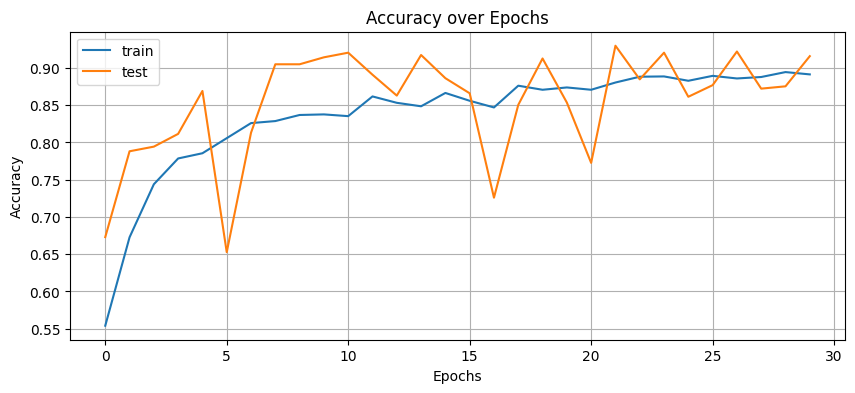

In [ ]:
#График кривой обучения бинарного классификатора
#Построение графика
plt.figure(figsize=(10,4))
plt.plot(history.history['acc'],label='train')
plt.plot(history.history['val_acc'],label='test')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.grid()
plt.legend()
plt.show()

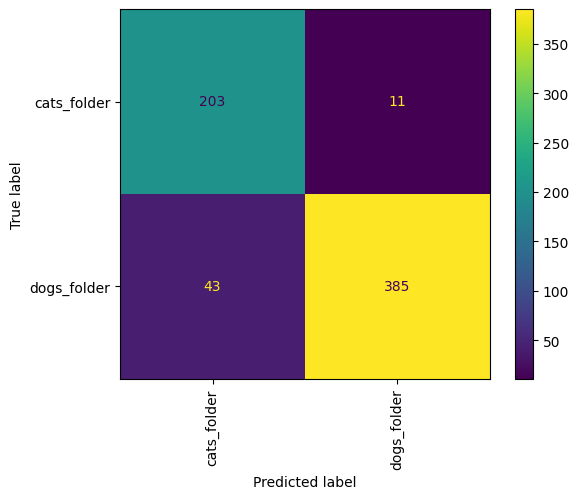

In [ ]:
#Матрица ошибок
pred_y = []
true_y = []
for x,y in ds_test:
  pred_y.extend(model.predict(x,verbose=0).argmax(axis=-1))
  true_y.extend(y)

ConfusionMatrixDisplay.from_predictions(true_y,pred_y,display_labels=classes)
plt.xticks(rotation=90)
plt.show()

--2025-04-16 04:47:08--  https://kot-pes.com/wp-content/uploads/2019/02/post_5c606e629f934.jpg
Resolving kot-pes.com (kot-pes.com)... 104.21.32.1, 104.21.80.1, 104.21.64.1, ...
Connecting to kot-pes.com (kot-pes.com)|104.21.32.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 161127 (157K) [image/jpeg]
Saving to: ‘post_5c606e629f934.jpg’

post_5c606e629f934. 100%[===================>] 157.35K  --.-KB/s    in 0.006s  

2025-04-16 04:47:09 (26.6 MB/s) - ‘post_5c606e629f934.jpg’ saved [161127/161127]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Предсказанный класс:  cats_folder


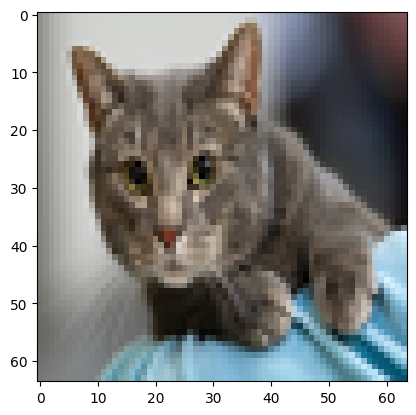

In [ ]:
#Проверка на отдельном изображении бинарного классификатора
!wget https://kot-pes.com/wp-content/uploads/2019/02/post_5c606e629f934.jpg
#!wget https://funik.ru/wp-content/uploads/2018/10/17478da42271207e1d86.jpg
img = np.array(Image.open('post_5c606e629f934.jpg').resize((64,64),Image.LANCZOS))
plt.imshow(img)

img_array = np.array(img).astype("float32") / 255.0
img_batch = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_batch)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = classes[predicted_class[0]]
print("Предсказанный класс: ", predicted_label)